<center><h1>Основы глубокого обучение</h1></center>
<center><h1>Фомин Иван Алексеевич, ДЗ-3</h1></center>

In [15]:
!python -V # Версия Python

Python 3.12.13


In [16]:
# Подавление предупреждений
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

# Импорт необходимых библиотек
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import yfinance as yf
import sklearn
import networkx as nx
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

### Руководство по интерпретации графиков

#### 1. Динамика обучения

**Что показывает:**
- Изменение величины ошибки (MSE) в процессе обучения
- Скорость и стабильность сходимости модели

**Как смотреть:**
- ✔️ Хорошо: Плавное уменьшение ошибки
- ⚠️ Плохо:
    - Резкие скачки ошибки
    - Отсутствие снижения после N эпох
    - Рост ошибки на поздних этапах

#### 2. Реальные и предсказанные значения

**Что показывает:**
- Точность модели в сравнении с идеальным прогнозом (красная пунктирная линия)
- Распределение ошибок (цвет точек)

**Как смотреть:**
- Чем ближе точки к диагонали - тем лучше
- Скопления точек в определенных областях указывают на систематические ошибки
- Яркие желтые точки - наибольшие ошибки прогнозирования

#### 3. Распределение ошибок

**Что показывает:**
- Статистику ошибок прогнозирования
- Смещение и форму распределения

**Как смотреть:**
- ✔️ Хорошо:
    - Распределение близко к нормальному
    - Пик около нуля
- ⚠️ Плохо:
    - Явное смещение в положительную/отрицательную сторону

#### 4. Скользящее среднее и волатильность

**Что показывает:**
- Основной тренд (синяя линия)
- Изменчивость цен (зеленая линия)
- Историческую динамику

**Как смотреть:**
- Пересечения цены и скользящего среднего - возможные точки разворота тренда
- Высокая волатильность - периоды нестабильности рынка

#### 5. Примеры прогнозов

**Что показывает:**
- Конкретные примеры работы модели:
    - Пунктирные линии: исторические данные
    - Красные точки: реальные значения
    - Зеленые точки: предсказания модели

**Как смотреть:**
- Сравнивать положение красных и зеленых точек  
- Анализировать, как модель реагирует на разные шаблоны

#### 6. Важность временных лагов

**Что показывает:**
- Значимость предыдущих дней для прогноза
- Какие исторические данные наиболее важны

**Как смотреть:**
- Высокие столбцы справа - модель учитывает недавние данные  
- Пики в определенных позициях - ключевые исторические события  

#### 7. Автокорреляция ошибок

**Что показывает:**
- Наличие шаблонов в ошибках прогнозирования
- Зависимость ошибок от предыдущих значений

**Как смотреть:**
- ✔️ Хорошо: Нет значимых корреляций (все значения в синей зоне)  
- ⚠️ Плохо:  
    - Выбросы за пределы доверительного интервала  
    - Повторяющиеся шаблоны

#### 8. 30-дневный прогноз

**Что показывает:**
- Предсказание модели на следующий месяц
- Точки прогноза с датами

**Как смотреть:**
- Анализировать общий тренд (рост/падение)
- Отмечайте резкие изменения направления
- Сравнить с текущими рыночными ожиданиями

#### 9. 3D визуализация tanh

**Что показывает:**  
- Поведение функции активации в трехмерном пространстве  
- Нелинейные свойства используемой активации  

**Как смотреть:**
- S-образная форма - характерная особенность tanh
- Значения в диапазоне $[-1, 1]$ - ограничение выходных значений

#### 10. Распределение весов

**Что показывает:**
- Статистику значений параметров модели
- Сбалансированность обучения

**Как смотреть:**
- ✔️ Хорошо: Симметричное распределение около нуля
- ⚠️ Плохо:
    - Смещенные распределения
    - Выбросы в крайних значениях

## Процесс обучения LSTM (с лекции)

[*********************100%***********************]  1 of 1 completed


Epoch 0, Loss: 0.000687
Epoch 10, Loss: 0.008412


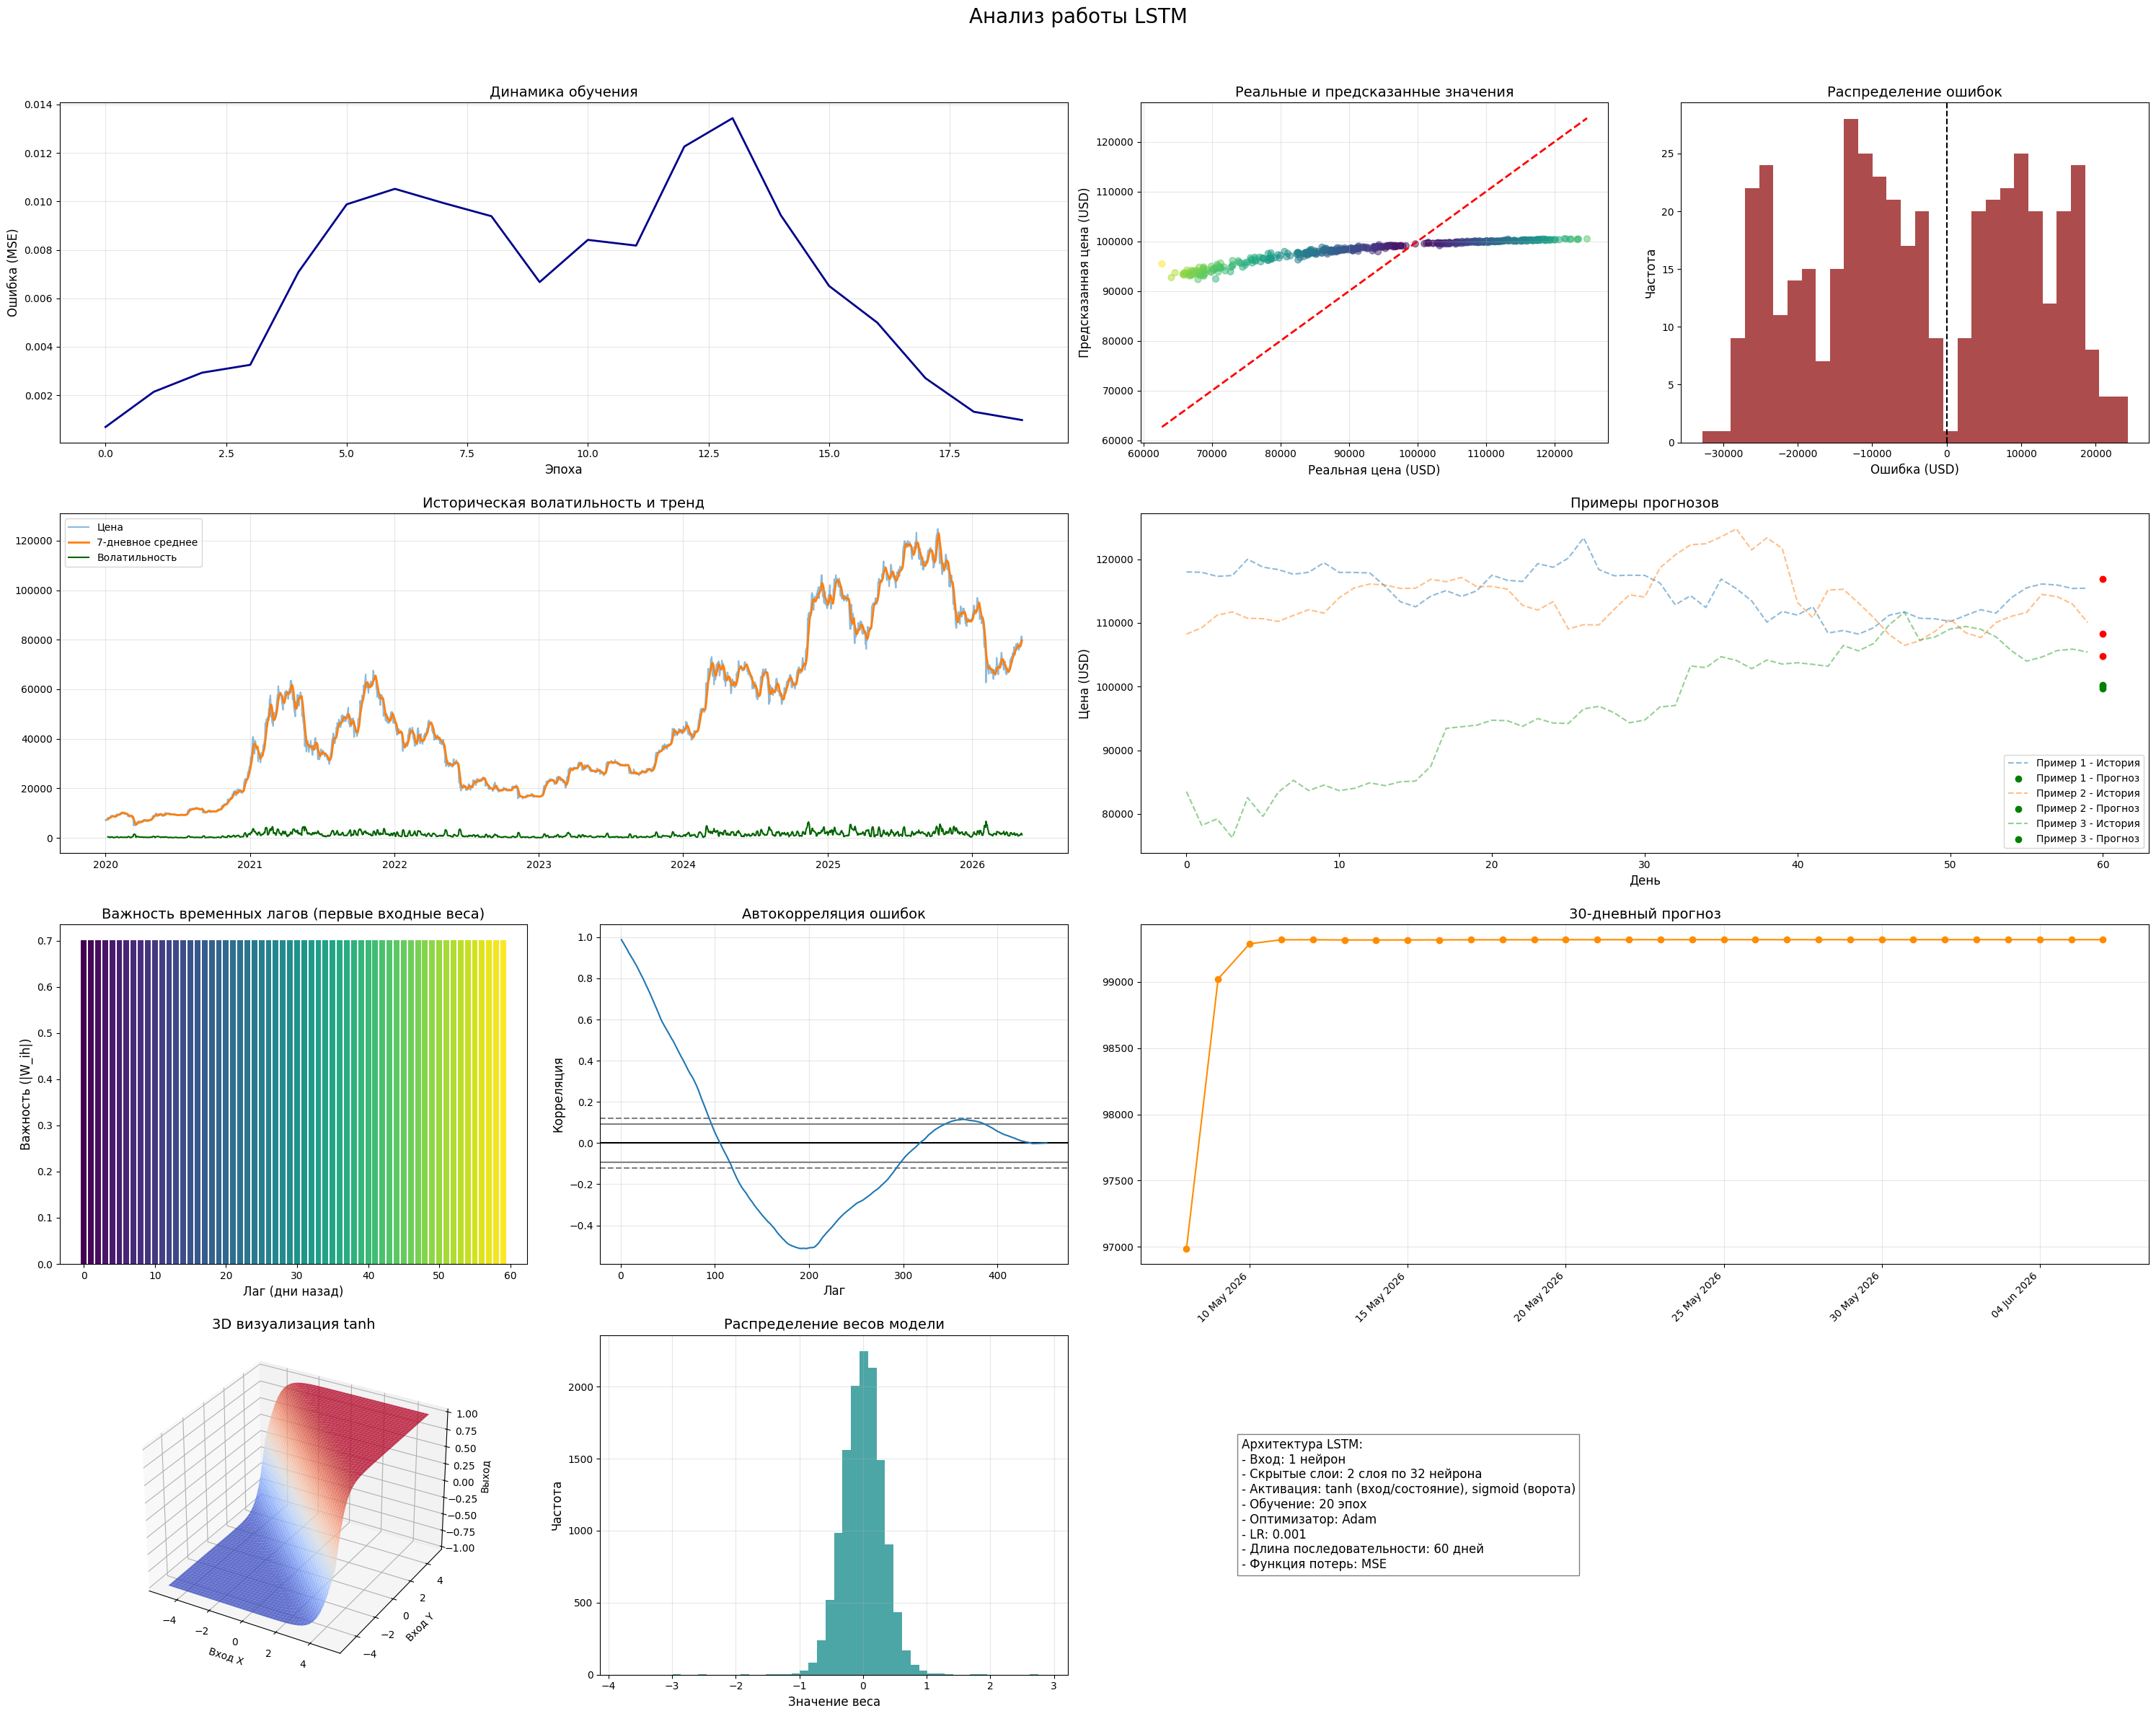

In [17]:
# Загрузка данных
ticker = "BTC-USD"
data = yf.download(ticker, start = "2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data = data[["Close"]]

# Нормализация данных
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_data = scaler.fit_transform(data)

# Создание последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return torch.FloatTensor(X), torch.FloatTensor(y)

seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Разделение данных
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Определение LSTM модели
class BitcoinLSTM(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 32, num_layers = 2):
        super(BitcoinLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
model = BitcoinLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Обучение модели
num_epochs = 20
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0)
        target = y_train[i].unsqueeze(0)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss:.6f}')

# Прогнозирование
def forecast(model, sequence, days = 30):
    current_seq = sequence.squeeze(0)
    predictions = []
    for _ in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        current_seq = torch.cat((current_seq[1:], pred))
    return predictions

# Генерация прогноза
last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast = forecast(model, input_tensor, days = 30)
forecast_prices = scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))

# Преобразование предсказаний и тестовых данных
model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0))
        test_predictions.append(pred.item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы LSTM", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(train_loss, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения", fontsize = 14)
ax1.set_xlabel("Эпоха", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions, alpha = 0.5, c = np.abs(y_test_original - test_predictions), cmap = "viridis", s = 40)
ax2.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window = window_size).mean()
data["Volatility"] = data["Close"].rolling(window = window_size).std()
ax4.plot(data["Close"], label = "Цена", alpha = 0.5)
ax4.plot(data["MA_7"], label = "7-дневное среднее", linewidth = 2)
ax4.plot(data["Volatility"], label = "Волатильность", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0))
    real = scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))

    ax5.plot(scaler.inverse_transform(seq), alpha = 0.5, linestyle = "--", label = f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color = "red", zorder = 5)
    ax5.scatter(len(seq), scaler.inverse_transform(pred.numpy()), color = "green", zorder = 5, label = f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize = 14)
ax5.set_xlabel("День", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для LSTM)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя LSTM
lstm_weights = model.lstm.weight_ih_l0.detach().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(lstm_weights[:model.hidden_size]), axis = 0)
ax6.bar(range(seq_length), lag_importance[:seq_length], color = plt.cm.viridis(np.linspace(0, 1, seq_length)))
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize = 14)
ax6.set_xlabel("Лаг (дни назад)", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Корреляция", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = 31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 6, linestyle = "-", color = "darkorange")
ax8.set_title("30-дневный прогноз", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 5))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().numpy().flatten())
ax10.hist(all_weights, bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Распределение весов модели", fontsize = 14)
ax10.set_xlabel("Значение веса", fontsize = 12)
ax10.set_ylabel("Частота", fontsize = 12)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = """Архитектура LSTM:
- Вход: 1 нейрон
- Скрытые слои: 2 слоя по 32 нейрона
- Активация: tanh (вход/состояние), sigmoid (ворота)
- Обучение: 20 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

## Домашнее задание

#### Задача

##### Понять почему 30-дневный прогноз цены на криптовалюту резко падает или вовсе не совпадает с реальными данными, визуализировать процессы обучения и сделать выводы.

#### Подсказки

1. Модели не учитывают важные факторы или данных для обучения недостаточно. Использовались ли только исторические цены закрытия, или были добавлены другие признаки? Данные включают только столбец `Close`, что ограничивает модель в изучении других факторов, влияющих на цену.
2. Проблема связана с нормализацией данных. Использовался `MinMaxScaler` в диапазоне $(0,1)$. Если последние значения в последовательности близки к **1**, то прогнозируемые значения могут выходить за пределы этого диапазона, что приводит к некорректным предсказаниям после обратного преобразования. Стоит попробовать другие методы нормализации или масштабирования.
3. Проверить, как реализовано прогнозирование на несколько шагов вперед. Функция `forecast` предсказывает каждый следующий день, добавляя его в последовательность. Однако накопление ошибок может привести к ошибке предсказаний. Нужно обратить внимание на то, как модель обрабатывает многократные предсказания: возможно, она начинает предсказывать среднее значение или шум после нескольких шагов.
4. Проверить качество обучения модели. Если модель недообучена или переобучена, то прогнозы будут неточными. Нужно посмотреть на график потерь во время обучения. Попробовать увеличить количество эпох, изменить скорость обучения или заменить функцию активации.
5. Проверить разделение данных на обучающую и тестовую выборки. Если тестовая выборка содержит необычные шаблоны или выбросы, модель будет плохо на них реагировать. Убедиться, что данные разделены правильно и временные зависимости учтены корректно.
6. Неадекватная архитектура модели. Проверить увеличение количества нейронов или слоев.
7. Обратить внимание на длину последовательности (`seq_length`). Если окно слишком большое или маленькое, модель будет не улавливать нужные зависимости.
8. Может проблема в самом характере данных? Цены волатильны и подвержены влиянию внешних факторов, которые не учтены в модели.
9. Может ошибки в коде?

## Исправленная версия LSTM

[*********************100%***********************]  1 of 1 completed


Epoch 0, Loss: 1.027463
Epoch 10, Loss: 0.101867
Epoch 20, Loss: 0.025249
Epoch 30, Loss: 0.012173
Epoch 40, Loss: 0.011160
Epoch 50, Loss: 0.010234
Epoch 60, Loss: 0.009444
Epoch 70, Loss: 0.008795
Epoch 80, Loss: 0.008247
Epoch 90, Loss: 0.007748
Epoch 100, Loss: 0.007335
Epoch 110, Loss: 0.006961
Epoch 120, Loss: 0.006607
Epoch 130, Loss: 0.006278
Epoch 140, Loss: 0.005976
Epoch 150, Loss: 0.005701
Epoch 160, Loss: 0.005456
Epoch 170, Loss: 0.005243
Epoch 180, Loss: 0.005113
Epoch 190, Loss: 0.006044


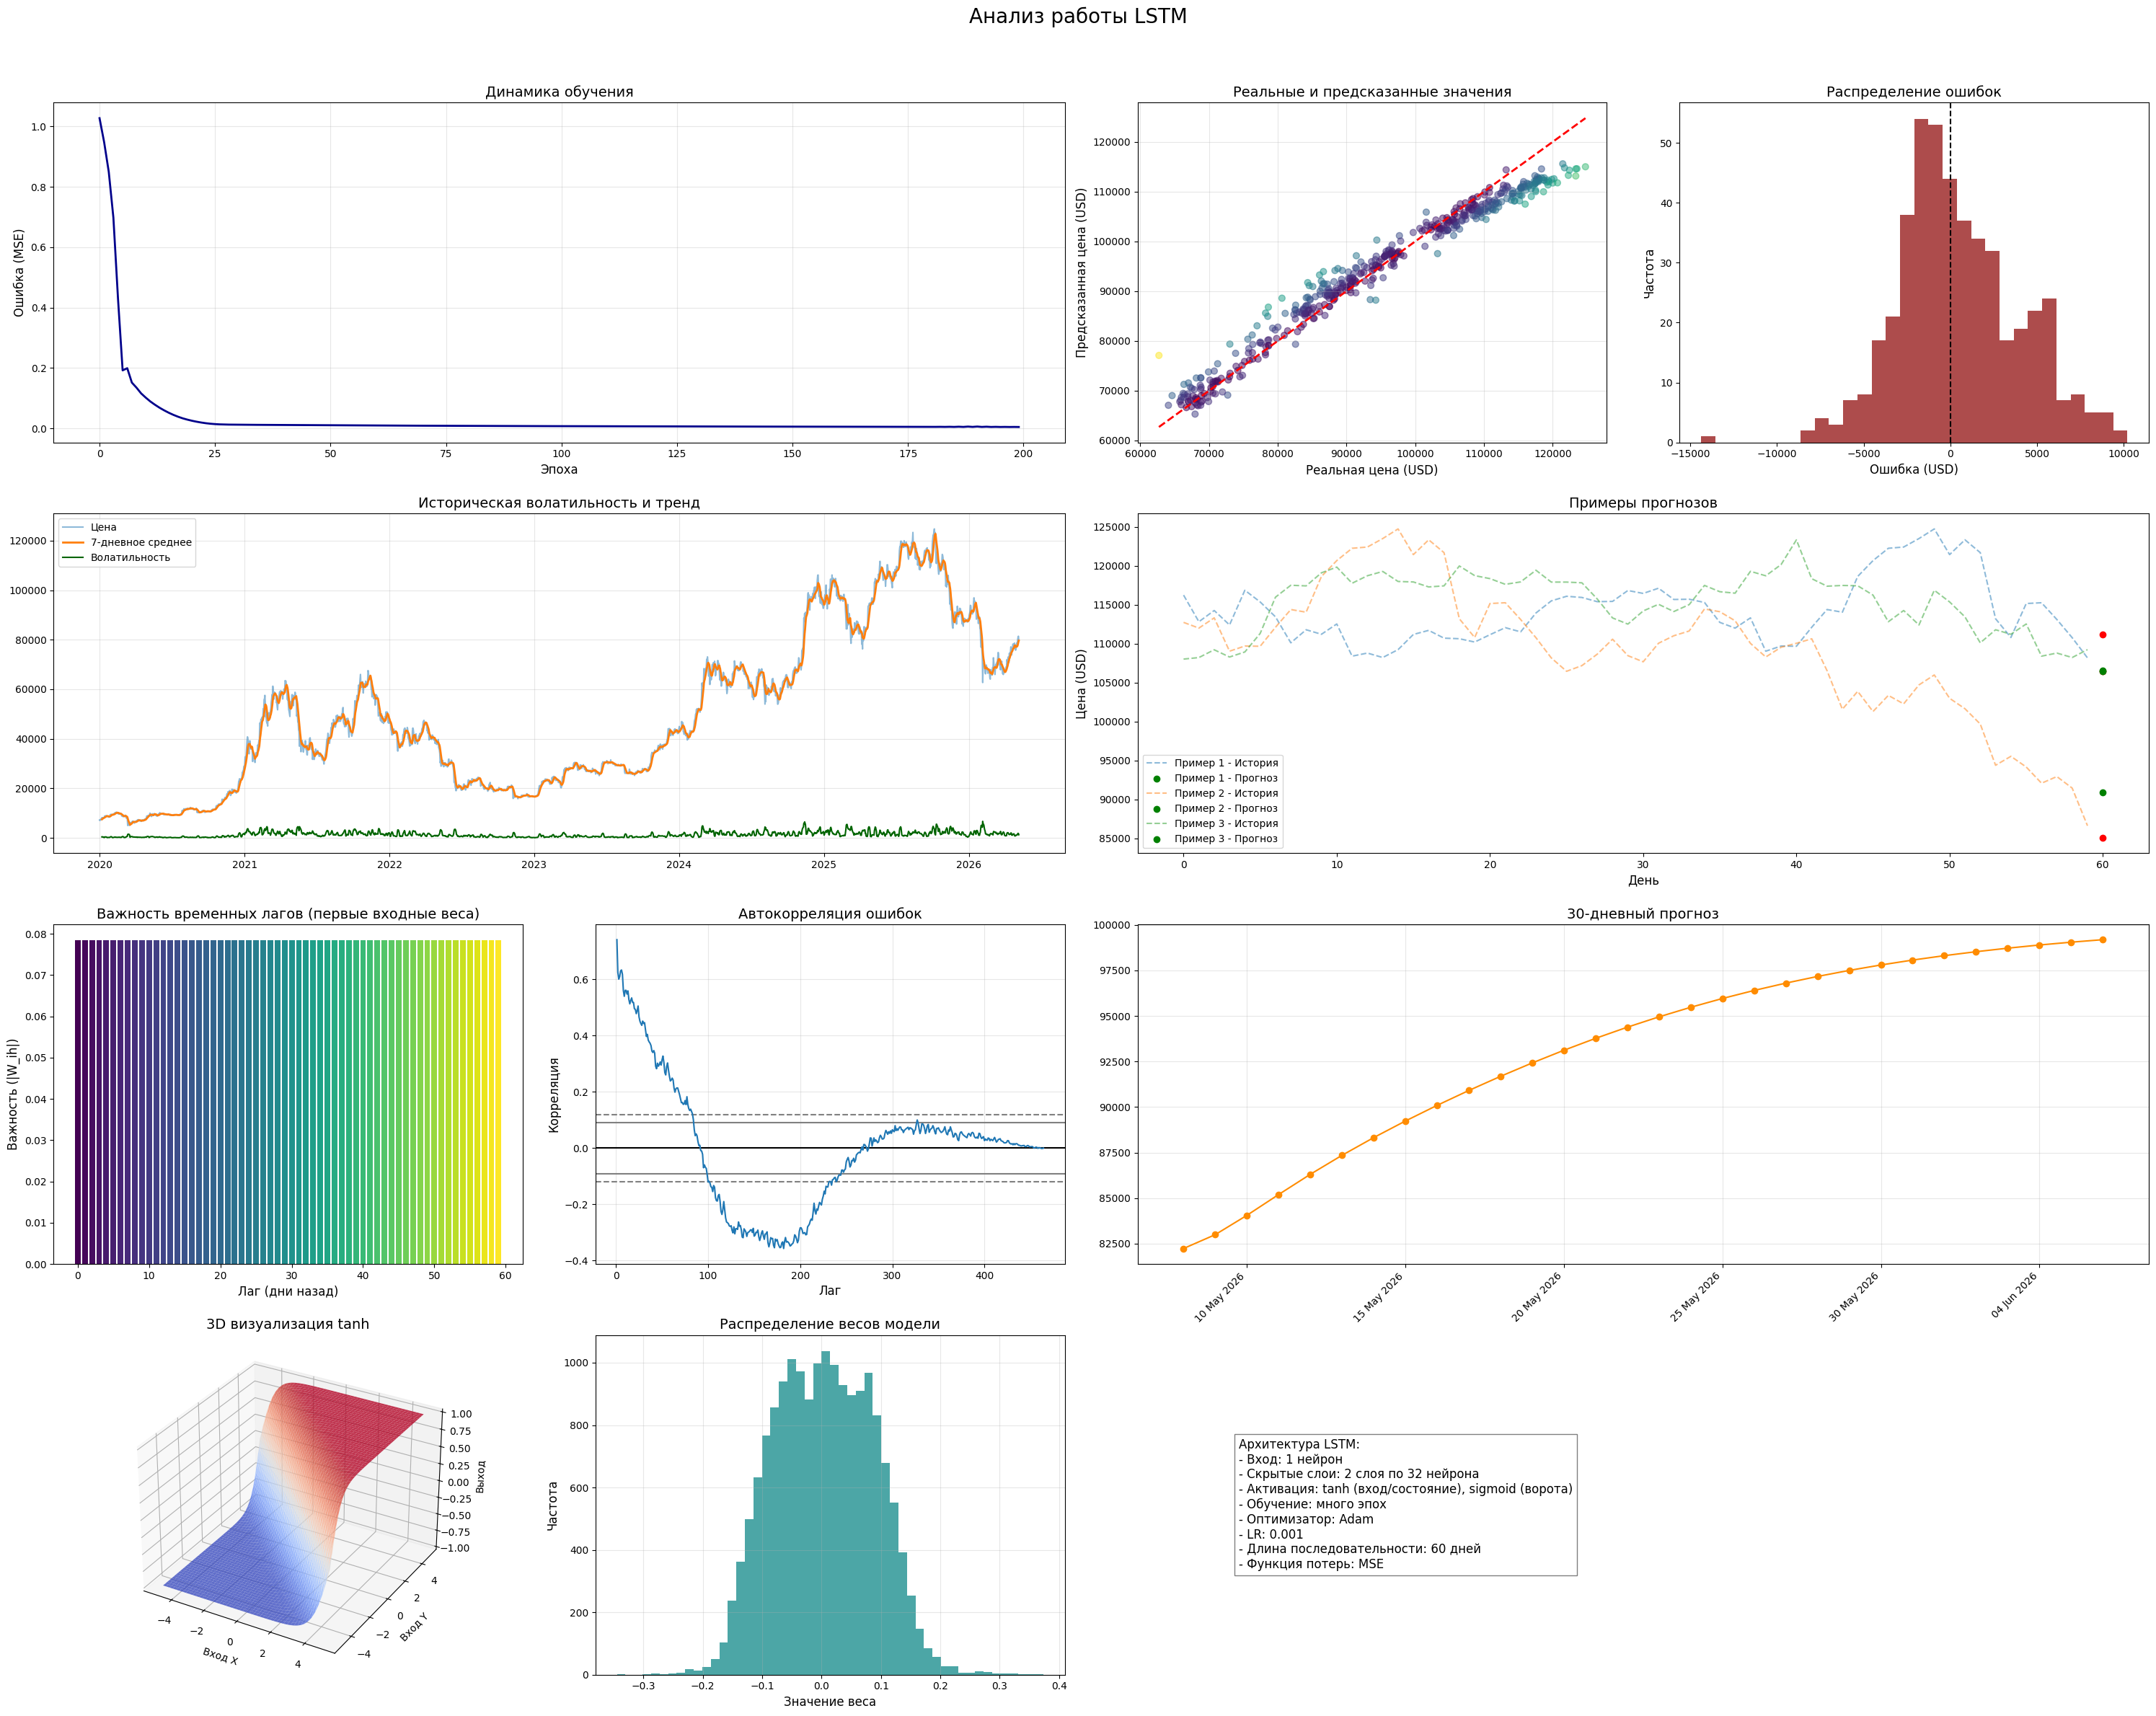

In [58]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

"""
Исправления:
Убрана утечка данных: scaler теперь обучается (fit) только на train, а не на всей выборке
MinMaxScaler заменён на StandardScaler: это помогло избавиться от скачка Loss в самом начале обучения (теперь график монотонно убывает, как и должно быть)
Разделение train/test перенесено до создания последовательностей
Для test добавлен отступ длиной seq_length, чтобы первое тестовое окно формировалось корректно
Увеличено количество перцептронов в слое, а слой оставлен всего 1 (увеличение количества слоёв ничего не дало)
Выбран более маленький шаг обучения, а также добавлена его оптимизация ReduceLROnPlateau
Обучение производится не по 1 объекту, а по батчам размера 32
Убрана ручная инициализация скрытых состояний LSTM: PyTorch делает это автоматически
Используем clip_grad_norm_ из библиотеки для нормализации градиентов
"""

# Загрузка данных
ticker = "BTC-USD"
data = yf.download(ticker, start="2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))
data = data[["Close"]].dropna().astype(np.float32)

# Разделение данных
seq_length = 60
split_idx = int(len(data) * 0.8)
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx - seq_length:].copy()

# Стандартизация данных
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data[["Close"]])
test_scaled = scaler.transform(test_data[["Close"]])

# Создание последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)


X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)


# Определение LSTM модели
class BitcoinLSTM(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 64, num_layers = 1):
        super(BitcoinLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Инициализация модели
model = BitcoinLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)

# Обучение модели
num_epochs = 200
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for inputs, target in train_loader:
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_loss.append(avg_loss)
    scheduler.step(avg_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss:.6f}')

# Прогнозирование
def forecast(model, sequence, days = 30):
    current_seq = sequence.squeeze(0)
    predictions = []
    for _ in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        current_seq = torch.cat((current_seq[1:], pred))
    return predictions

# Генерация прогноза
last_sequence = test_scaled[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast = forecast(model, input_tensor, days = 30)
forecast_prices = scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))

# Преобразование предсказаний и тестовых данных
model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0))
        test_predictions.append(pred.item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize = (30, 25))
plt.suptitle("Анализ работы LSTM", y = 0.95, fontsize = 20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan = 2)
ax1.plot(train_loss, color = "darkblue", linewidth = 2)
ax1.set_title("Динамика обучения", fontsize = 14)
ax1.set_xlabel("Эпоха", fontsize = 12)
ax1.set_ylabel("Ошибка (MSE)", fontsize = 12)
ax1.grid(True, alpha = 0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions, alpha = 0.5, c = np.abs(y_test_original - test_predictions), cmap = "viridis", s = 40)
ax2.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], "--r", linewidth = 2)
ax2.set_title("Реальные и предсказанные значения", fontsize = 14)
ax2.set_xlabel("Реальная цена (USD)", fontsize = 12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize = 12)
ax2.grid(alpha = 0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins = 30, color = "darkred", alpha = 0.7)
ax3.set_title("Распределение ошибок", fontsize = 14)
ax3.set_xlabel("Ошибка (USD)", fontsize = 12)
ax3.set_ylabel("Частота", fontsize = 12)
ax3.axvline(x = 0, color = "black", linestyle = "--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan = 2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window = window_size).mean()
data["Volatility"] = data["Close"].rolling(window = window_size).std()
ax4.plot(data["Close"], label = "Цена", alpha = 0.5)
ax4.plot(data["MA_7"], label = "7-дневное среднее", linewidth = 2)
ax4.plot(data["Volatility"], label = "Волатильность", color = "darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize = 14)
ax4.legend()
ax4.grid(alpha = 0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan = 2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0))
    real = scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))

    ax5.plot(scaler.inverse_transform(seq), alpha = 0.5, linestyle = "--", label = f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color = "red", zorder = 5)
    ax5.scatter(len(seq), scaler.inverse_transform(pred.numpy()), color = "green", zorder = 5, label = f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize = 14)
ax5.set_xlabel("День", fontsize = 12)
ax5.set_ylabel("Цена (USD)", fontsize = 12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для LSTM)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя LSTM
lstm_weights = model.lstm.weight_ih_l0.detach().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(lstm_weights[:model.hidden_size]), axis = 0)
ax6.bar(range(seq_length), lag_importance[:seq_length], color = plt.cm.viridis(np.linspace(0, 1, seq_length)))
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize = 14)
ax6.set_xlabel("Лаг (дни назад)", fontsize = 12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize = 12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax = ax7)
ax7.set_title("Автокорреляция ошибок", fontsize = 14)
ax7.set_xlabel("Лаг", fontsize = 12)
ax7.set_ylabel("Корреляция", fontsize = 12)
ax7.grid(alpha = 0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan = 2)
forecast_dates = pd.date_range(start = data.index[-1], periods = 31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker = "o", markersize = 6, linestyle = "-", color = "darkorange")
ax8.set_title("30-дневный прогноз", fontsize = 14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval = 5))
plt.setp(ax8.get_xticklabels(), rotation = 45, ha = "right")
ax8.grid(True, alpha = 0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection = "3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap = "coolwarm", alpha = 0.8)
ax9.set_title("3D визуализация tanh", fontsize = 14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().numpy().flatten())
ax10.hist(all_weights, bins = 50, color = "teal", alpha = 0.7)
ax10.set_title("Распределение весов модели", fontsize = 14)
ax10.set_xlabel("Значение веса", fontsize = 12)
ax10.set_ylabel("Частота", fontsize = 12)
ax10.grid(True, alpha = 0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan = 2)
ax11.axis("off")
text = """Архитектура LSTM:
- Вход: 1 нейрон
- Скрытые слои: 2 слоя по 32 нейрона
- Активация: tanh (вход/состояние), sigmoid (ворота)
- Обучение: много эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize = 12, va = "center", bbox = dict(facecolor = "white", alpha = 0.5))

plt.tight_layout(rect = [0, 0, 1, 0.93])
plt.show()

У меня более менее получилось довести точки до красной пунктирной диагонали (на 2 графике)

Вообще, первое, что бросилось в глаза $-$ это то, что в качестве таргета выбрана просто цена закрытия. Это неправильно, потому что при работе с временными рядами их по-хорошему нужно привести к стационарному виду. А уже потом с помощью обратных преобразований понимать реальное значение цены.

Я пишу курсовой проект по машинному обучению на похожую тему (только не по биткоину, а по акциям NVIDIA), и там я решил сделать таргетом лог-доходность , а не просто "сырую" цену. Возможно, здесь тоже следовало сделать подобный таргет. Но ведь тогда это полностью меняет задачу (и от нас не требуется так делать), или не так?

**Выводы**:
1) Если сильно упростить архитектуру LSTM, то модель недообучается, маленькие и большие ценовые значения не предсказываются нормально. Сильно усложнить $-$ обучение становится слишком затратным.
2) В целом, есть такое, что маленькие ценовые значения предсказываются выше реальных, а большие $-$ ниже. Я почти уверен, что это происходит из-за неправильного выбора таргета. (В метриках берётся разность между предсказанным значением и действительным, но если у нас эти значения получились 10 и 11 соответственно, то ошибка будет такой же, как и у 60010 с 60011, что в действительности неверно $-$ в первом случае ошибка больше).
3) Данные сложные, поэтому модели требуется больше эпох, иначе она может недообучиться.
4) Важно правильно готовить данные (стандартизировать и тп) и прогонять их через нейросеть (не единичными "шумными" батчами).
5) Хорошая визуализация позволяет грамотно анализировать качество текущей модели.
6) Нужно следить за тем, чтобы не было утечек данных.
7) Выбор гиперпараметров может сильно влиять на ход обучения.